In [1]:
# ============================================================
# 02_TRAIN_AND_INFER: FINETUNE YOLO + SUBMISSION
# ============================================================

!pip install -q "numpy<2.0" "protobuf~=3.20.0" ultralytics==8.3.221

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 32.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 99.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

✓ Running on device: cuda
🚀 START INFERENCE | Weights: YOLO=0.4, Siam=0.3, Color=0.3
✓ Loaded Siamese Model


  0%|          | 0/6 [00:00<?, ?it/s]


✅ DONE. Mean ST-IoU Score: 0.651489
Results saved to: predictions.json

VISUALIZING SAMPLE RESULTS

📺 Video: CardboardBox_1 | Frames: [1433, 3171, 5188]


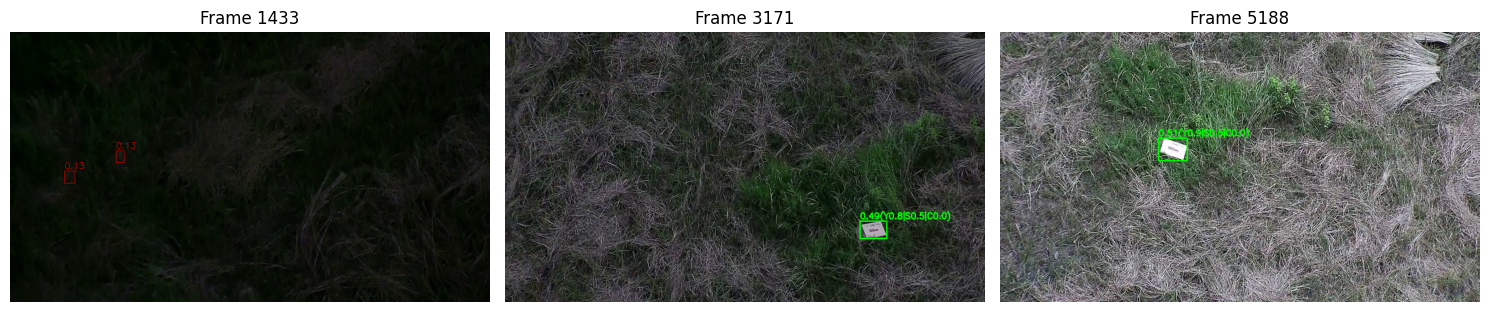


📺 Video: LifeJacket_1 | Frames: [1067, 1382, 1789]


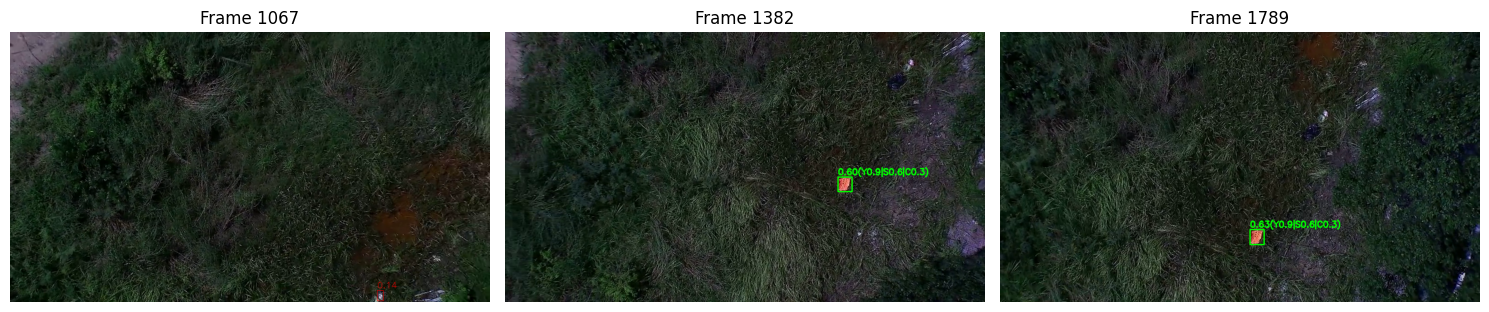


📺 Video: CardboardBox_0 | Frames: [220, 3124, 3132]


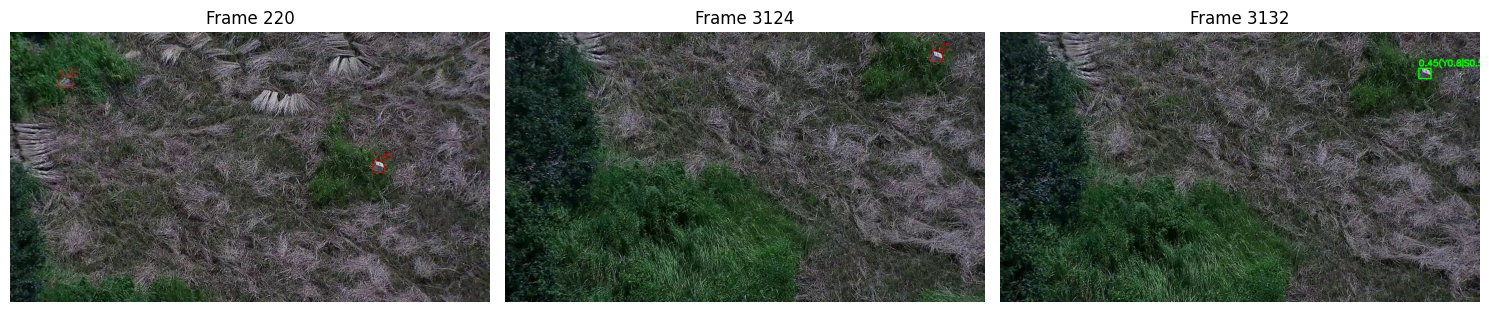

In [ ]:
# ==============================================================================
# FINAL INTEGRATED SCRIPT: YOLO + SIAMESE + COLOR FILTER + VISUALIZATION
# ==============================================================================

# --- 1. IMPORTS & CONFIGURATION ---
import os
import json
import random
import cv2
import numpy as np
from PIL import Image
from tqdm.notebook import tqdm  # Dùng tqdm.notebook cho đẹp trên Kaggle/Colab
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import mobilenet_v3_small
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ================= CẤU HÌNH ĐƯỜNG DẪN (SỬA Ở ĐÂY) =================
TEST_DATA_DIR      = '/kaggle/input/data-gannhantay-zalo/public_test_remake_full/public_test_remake_full/samples'
GT_ANN_PATH        = '/kaggle/input/data-gannhantay-zalo/public_test_remake_full/public_test_remake_full/annotations/drone_annotations.json'
OUTPUT_FILE        = 'predictions.json'

# Đường dẫn weights model
YOLO_MODEL_PATH    = '/kaggle/input/weight-best-syn/yolo_drone_700.pt' # model detect
SIAMESE_MODEL_PATH = '/kaggle/input/weight-best-syn/siamese_mobilenet_best_new.pth' # model matching

# Tham số ngưỡng & Trọng số
CONFIDENCE_THRESHOLD = 0.05
MATCHING_THRESHOLD   = 0.45  # Điểm tổng kết phải > 0.45 mới nhận
YOLO_ONLY_THRESHOLD  = 0.2   # Nếu không có Siamese thì YOLO conf phải > 0.3

# Trọng số điểm (Tổng nên = 1.0)
WEIGHT_YOLO    = 0.4  # Độ tin cậy của YOLO (Objectness)
WEIGHT_SIAMESE = 0.3  # Độ giống về Hình dáng (Shape)
WEIGHT_COLOR   = 0.3  # Độ giống về Màu sắc (Color)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Running on device: {DEVICE}")

# --- 2. MODEL DEFINITIONS ---

class SiameseMobileNet(nn.Module):
    def __init__(self, embedding_dim=576):
        super(SiameseMobileNet, self).__init__()
        # Load backbone (không cần pretrained weights lúc inference vì sẽ load checkpoint)
        full_model = mobilenet_v3_small(weights=None)
        self.features = full_model.features
        self.projection = nn.Sequential(
            nn.Linear(embedding_dim, 256),
            nn.BatchNorm1d(256), 
            nn.ReLU(inplace=True),
            nn.Linear(256, 128)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = F.adaptive_avg_pool2d(x, (1, 1)).flatten(1)
        x = self.projection(x)
        return F.normalize(x, p=2, dim=1)

def get_inference_transforms():
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                             std=[0.229, 0.224, 0.225]),
    ])

# --- 3. HELPER FUNCTIONS (LOADING & COLOR) ---

def load_reference_embeddings(video_folder, model, transform):
    """Tính embedding trung bình của 3 ảnh tham chiếu"""
    obj_dir = os.path.join(TEST_DATA_DIR, video_folder, "object_images")
    if not os.path.exists(obj_dir): return None
    
    img_paths = sorted([
        os.path.join(obj_dir, f) for f in os.listdir(obj_dir) 
        if f.lower().endswith(('.jpg','.jpeg','.png'))
    ])
    
    if not img_paths: return None
    
    tensors = []
    for p in img_paths:
        img = cv2.imread(p)
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        tensors.append(transform(Image.fromarray(img)))
    
    if not tensors: return None
    
    batch = torch.stack(tensors).to(DEVICE)
    with torch.no_grad():
        embs = model(batch)
        # Lấy trung bình cộng của các vectors
        mean_emb = torch.mean(embs, dim=0, keepdim=True)
        mean_emb = F.normalize(mean_emb, p=2, dim=1)
        
    return mean_emb

def compute_hs_histogram(img_bgr):
    """Tính Histogram 2D (Hue-Saturation), bỏ qua Value để chống nhiễu sáng"""
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    # Mask loại bỏ pixel quá tối/sáng/nhạt (nền đường, mây...)
    mask = cv2.inRange(hsv, np.array([0, 30, 30]), np.array([180, 255, 255]))
    
    # Hue: 30 bins, Sat: 32 bins
    hist = cv2.calcHist([hsv], [0, 1], mask, [30, 32], [0, 180, 0, 256])
    cv2.normalize(hist, hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
    return hist

def load_reference_histogram(video_folder):
    """Tính Histogram màu trung bình của 3 ảnh tham chiếu"""
    obj_dir = os.path.join(TEST_DATA_DIR, video_folder, "object_images")
    if not os.path.exists(obj_dir): return None
    
    img_paths = [os.path.join(obj_dir, f) for f in os.listdir(obj_dir) if f.endswith(('.jpg','.png'))]
    
    agg_hist = None
    for p in img_paths:
        img = cv2.imread(p)
        if img is None: continue
        hist = compute_hs_histogram(img)
        if agg_hist is None: agg_hist = hist
        else: agg_hist += hist
        
    if agg_hist is not None:
        cv2.normalize(agg_hist, agg_hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
    return agg_hist

def calculate_color_score(crop_img, ref_hist):
    """So sánh màu sắc giữa crop và ref"""
    if ref_hist is None or crop_img is None or crop_img.size == 0: return 0.0
    crop_hist = compute_hs_histogram(crop_img)
    # Correlation: 1.0 là giống hệt
    score = cv2.compareHist(ref_hist, crop_hist, cv2.HISTCMP_CORREL)
    return max(0.0, score)

# --- 4. EVALUATION & VISUALIZATION HELPERS ---

def load_gt_annotations(gt_path):
    if not os.path.exists(gt_path): return {}
    with open(gt_path, 'r') as f: records = json.load(f)
    gt_map = {}
    for rec in records:
        vid = rec.get("video_id")
        if not vid: continue
        frame2bbox = {}
        for interval in rec.get("annotations", []):
            for b in interval.get("bboxes", []):
                frame2bbox[int(b["frame"])] = [int(b["x1"]), int(b["y1"]), int(b["x2"]), int(b["y2"])]
        gt_map[vid] = frame2bbox
    return gt_map

def iou_box(b1, b2):
    x1, y1, x2, y2 = b1
    x1p, y1p, x2p, y2p = b2
    ix1, iy1 = max(x1, x1p), max(y1, y1p)
    ix2, iy2 = min(x2, x2p), min(y2, y2p)
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    inter = iw * ih
    area1 = max(0, x2 - x1) * max(0, y2 - y1)
    area2 = max(0, x2p - x1p) * max(0, y2p - y1p)
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0

def compute_st_iou_video(gt_frames, pred_frames):
    inter = set(gt_frames.keys()) & set(pred_frames.keys())
    union = set(gt_frames.keys()) | set(pred_frames.keys())
    if not union: return 0.0
    s = 0.0
    for f in inter:
        s += iou_box(gt_frames[f], pred_frames[f])
    return s / float(len(union))

def visualize_sample_results(all_predictions, debug_info, num_videos=3, num_frames_per_video=3):
    print("\n" + "="*50 + "\nVISUALIZING SAMPLE RESULTS\n" + "="*50)
    valid_preds = [p for p in all_predictions if len(p["detections"]) > 0 and len(p["detections"][0]["bboxes"]) > 0]
    
    if not valid_preds:
        print(" Không có video nào có detection.")
        return

    selected = random.sample(valid_preds, min(len(valid_preds), num_videos))

    for pred in selected:
        vid_id = pred["video_id"]
        video_info = debug_info.get(vid_id, {})
        if not video_info: continue

        frame_indices = sorted(list(video_info.keys()))
        chosen_frames = random.sample(frame_indices, min(len(frame_indices), num_frames_per_video))
        chosen_frames.sort()

        print(f"\n📺 Video: {vid_id} | Frames: {chosen_frames}")
        vid_path = os.path.join(TEST_DATA_DIR, vid_id, "drone_video.mp4")
        cap = cv2.VideoCapture(vid_path)

        plt.figure(figsize=(5 * len(chosen_frames), 5))
        for i, f_idx in enumerate(chosen_frames):
            cap.set(cv2.CAP_PROP_POS_FRAMES, f_idx)
            ret, frame = cap.read()
            if not ret: continue

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            candidates = video_info.get(f_idx, [])

            for cand in candidates:
                x1, y1, x2, y2 = map(int, cand["bbox"])
                final_s = cand["final_score"]
                scores = cand.get("scores", (0,0,0)) # (Y, S, C)
                
                if cand["is_best"]:
                    color = (0, 255, 0)
                    # Hiển thị chi tiết điểm: Total (Yolo|Siamese|Color)
                    label = f"{final_s:.2f}(Y{scores[0]:.1f}|S{scores[1]:.1f}|C{scores[2]:.1f})"
                    thick = 2
                else:
                    color = (255, 0, 0)
                    label = f"{final_s:.2f}"
                    thick = 1

                cv2.rectangle(frame_rgb, (x1, y1), (x2, y2), color, thick)
                cv2.putText(frame_rgb, label, (x1, max(15, y1 - 5)), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, thick)

            plt.subplot(1, len(chosen_frames), i + 1)
            plt.imshow(frame_rgb)
            plt.axis("off")
            plt.title(f"Frame {f_idx}")

        plt.tight_layout()
        plt.show()
        cap.release()

# --- 5. TEMPORAL SMOOTHING ---

def temporal_smooth_detections(frame_best, max_frame_idx, min_seg_len=5, max_gap=4):
    T = max_frame_idx + 1
    det = [None] * T
    for f, info in frame_best.items():
        if 0 <= f < T: det[f] = info

    # Fill gaps
    for i in range(T - max_gap):
        if det[i] is not None:
            next_idx = -1
            for k in range(1, max_gap + 2):
                if i + k < T and det[i+k] is not None:
                    next_idx = i + k
                    break
            if next_idx != -1 and next_idx > i + 1:
                b1, s1 = det[i]['bbox'], det[i]['score']
                b2, s2 = det[next_idx]['bbox'], det[next_idx]['score']
                steps = next_idx - i
                for step in range(1, steps):
                    alpha = step / steps
                    ibox = [b1[j]*(1-alpha) + b2[j]*alpha for j in range(4)]
                    iscore = s1*(1-alpha) + s2*alpha
                    det[i+step] = {'bbox': ibox, 'score': iscore}

    # Remove short segments
    i = 0
    while i < T:
        if det[i] is not None:
            j = i
            while j + 1 < T and det[j+1] is not None: j += 1
            if j - i + 1 < min_seg_len:
                for k in range(i, j + 1): det[k] = None
            i = j + 1
        else:
            i += 1
            
    out = []
    for f in range(T):
        if det[f]:
            x1,y1,x2,y2 = det[f]['bbox']
            out.append({"frame": f, "x1": int(x1), "y1": int(y1), "x2": int(x2), "y2": int(y2)})
    return out

# --- 6. MAIN EXECUTION ---

def main():
    print(f" START INFERENCE | Weights: YOLO={WEIGHT_YOLO}, Siam={WEIGHT_SIAMESE}, Color={WEIGHT_COLOR}")
    
    # 1. Load YOLO
    yolo = YOLO(YOLO_MODEL_PATH)
    
    # 2. Load Siamese
    siam = SiameseMobileNet().to(DEVICE)
    use_siam = False
    if os.path.exists(SIAMESE_MODEL_PATH):
        siam.load_state_dict(torch.load(SIAMESE_MODEL_PATH, map_location=DEVICE))
        siam.eval()
        use_siam = True
        print("✓ Loaded Siamese Model")
    else: 
        print(" Siamese weights not found - Using YOLO Only fallback")

    # 3. Load GT for scoring
    gt_map = load_gt_annotations(GT_ANN_PATH)
    
    transform = get_inference_transforms()
    all_preds = []
    st_iou_per_video = {}
    debug_info = {} # Lưu info để visualize
    
    try:
        video_folders = sorted([f for f in os.listdir(TEST_DATA_DIR) if os.path.isdir(os.path.join(TEST_DATA_DIR, f))])
    except:
        print(" Lỗi đường dẫn TEST_DATA_DIR")
        return

    for vid_id in tqdm(video_folders):
        vid_path = os.path.join(TEST_DATA_DIR, vid_id, "drone_video.mp4")
        if not os.path.exists(vid_path):
            all_preds.append({"video_id": vid_id, "detections": []}); continue

        # --- PREPARE REFERENCES ---
        ref_emb = load_reference_embeddings(vid_id, siam, transform) if use_siam else None
        ref_hist = load_reference_histogram(vid_id)

        # --- RUN DETECTION ---
        results = yolo.predict(vid_path, stream=True, conf=CONFIDENCE_THRESHOLD, verbose=False)
        
        frame_best = {}
        frame_debug = {}
        max_frame_idx = -1

        for f_idx, res in enumerate(results):
            max_frame_idx = max(max_frame_idx, f_idx)
            if not res.boxes: continue
            
            boxes = res.boxes.xyxy.cpu().numpy()
            confs = res.boxes.conf.cpu().numpy()
            orig_img = res.orig_img
            h, w = orig_img.shape[:2]
            
            pil_img = Image.fromarray(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
            
            best_score = -1.0
            best_box = None
            
            # --- PROCESS CANDIDATES ---
            cand_tensors = []
            cand_bgrs = []
            valid_indices = []

            for i, box in enumerate(boxes):
                x1,y1,x2,y2 = map(int, box)
                x1=max(0,x1); y1=max(0,y1); x2=min(w,x2); y2=min(h,y2)
                if x2<=x1+5 or y2<=y1+5: continue
                
                valid_indices.append(i)
                cand_tensors.append(transform(pil_img.crop((x1,y1,x2,y2))))
                cand_bgrs.append(orig_img[y1:y2, x1:x2])

            if not cand_tensors: continue

            # --- CALCULATE SCORES ---
            siam_scores = np.zeros(len(cand_tensors))
            color_scores = np.zeros(len(cand_tensors))

            # A. Siamese Matching
            if ref_emb is not None:
                with torch.no_grad():
                    batch = torch.stack(cand_tensors).to(DEVICE)
                    feats = siam(batch)
                    dists = torch.cdist(ref_emb, feats).cpu().numpy()[0]
                    siam_scores = np.maximum(0, 1.0 - dists/2.0)
            
            # B. Color Matching
            if ref_hist is not None:
                for k, crop_bgr in enumerate(cand_bgrs):
                    color_scores[k] = calculate_color_score(crop_bgr, ref_hist)

            # C. Combine & Select
            candidates_info = []
            for k, idx in enumerate(valid_indices):
                yolo_s = confs[idx]
                siam_s = siam_scores[k]
                col_s  = color_scores[k]
                
                # Dynamic weighting
                w_y, w_s, w_c = WEIGHT_YOLO, 0, 0
                if ref_emb is not None: w_s = WEIGHT_SIAMESE
                if ref_hist is not None: w_c = WEIGHT_COLOR
                
                total_w = w_y + w_s + w_c
                if total_w > 0:
                    final_score = (w_y*yolo_s + w_s*siam_s + w_c*col_s) / total_w
                else:
                    final_score = yolo_s

                candidates_info.append({
                    "bbox": boxes[idx].tolist(),
                    "final_score": final_score,
                    "scores": (yolo_s, siam_s, col_s),
                    "is_best": False
                })

                if final_score > best_score:
                    best_score = final_score
                    best_box = boxes[idx]

            frame_debug[f_idx] = candidates_info

            # Thresholding
            thresh = MATCHING_THRESHOLD if (ref_emb is not None) else YOLO_ONLY_THRESHOLD
            if best_box is not None and best_score >= thresh:
                frame_best[f_idx] = {'bbox': best_box.tolist(), 'score': float(best_score)}
                # Mark best in debug info
                for ci in frame_debug[f_idx]:
                    if ci["bbox"] == best_box.tolist():
                        ci["is_best"] = True; break

        debug_info[vid_id] = frame_debug

        # --- POST-PROCESSING ---
        final_bboxes = []
        if frame_best:
            final_bboxes = temporal_smooth_detections(frame_best, max_frame_idx)
        
        all_preds.append({"video_id": vid_id, "detections": [{"bboxes": final_bboxes}] if final_bboxes else []})

        # ST-IoU Calculation
        gt_frames = gt_map.get(vid_id, {})
        pred_frames = {b["frame"]: [b["x1"], b["y1"], b["x2"], b["y2"]] for b in final_bboxes}
        st_iou_per_video[vid_id] = compute_st_iou_video(gt_frames, pred_frames)

    # --- SAVE & REPORT ---
    with open(OUTPUT_FILE, 'w') as f:
        json.dump(all_preds, f, indent=4)
    
    mean_score = sum(st_iou_per_video.values()) / max(1, len(st_iou_per_video))
    print(f"\n DONE. Mean ST-IoU Score: {mean_score:.6f}")
    print(f"Results saved to: {OUTPUT_FILE}")
    
    # --- VISUALIZE ---
    visualize_sample_results(all_preds, debug_info, num_videos=3)

if __name__ == "__main__":
    main()